In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("monthly_milk_production.csv")

# Convert to datetime
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 168 entries, 1962-01-01 to 1975-12-01
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Production  168 non-null    int64
dtypes: int64(1)
memory usage: 2.6 KB
None
       Production
count  168.000000
mean   754.708333
std    102.204524
min    553.000000
25%    677.750000
50%    761.000000
75%    824.500000
max    969.000000


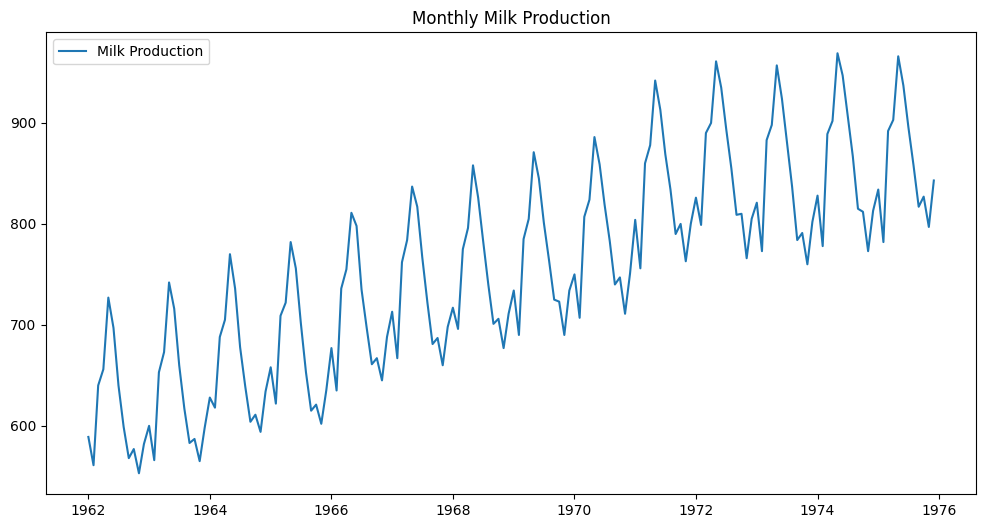

In [3]:
#Plot time series
plt.figure(figsize=(12,6))
plt.plot(df, label='Milk Production')
plt.title("Monthly Milk Production")
plt.legend()
plt.show()

In [4]:
print(df.isnull().sum())

Production    0
dtype: int64


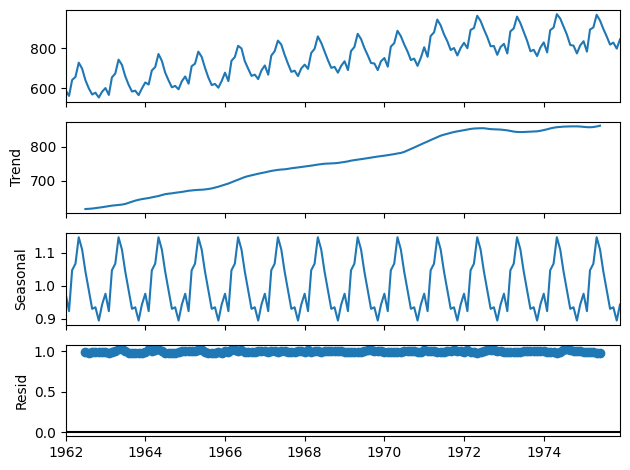

In [5]:
#check seasonality
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(df, model='multiplicative')
decomposition.plot()
plt.show()

In [6]:
#scaling
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)

In [7]:
#Create Sequences
import numpy as np

def create_sequences(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size])
    return np.array(X), np.array(y)

window_size = 12
X, y = create_sequences(scaled_data, window_size)

In [8]:
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, GRU

In [10]:
#RNN Model
rnn_model = Sequential([
    SimpleRNN(50, activation='relu', input_shape=(window_size,1)),
    Dense(1)
])

rnn_model.compile(optimizer='adam', loss='mse')
rnn_model.fit(X_train, y_train, epochs=20, batch_size=16)



Epoch 1/20

8/8 [==============================] - 3s 8ms/step - loss: 0.2593
Epoch 2/20
8/8 [==============================] - 0s 6ms/step - loss: 0.0541
Epoch 3/20
8/8 [==============================] - 0s 6ms/step - loss: 0.0344
Epoch 4/20
8/8 [==============================] - 0s 6ms/step - loss: 0.0212
Epoch 5/20
8/8 [==============================] - 0s 4ms/step - loss: 0.0206
Epoch 6/20
8/8 [==============================] - 0s 7ms/step - loss: 0.0159
Epoch 7/20
8/8 [==============================] - 0s 7ms/step - loss: 0.0141
Epoch 8/20
8/8 [==============================] - 0s 11ms/step - loss: 0.0120
Epoch 9/20
8/8 [==============================] - 0s 6ms/step - loss: 0.0100
Epoch 10/20
8/8 [==============================] - 0s 6ms/step - loss: 0.0089
Epoch 11/20
8/8 [==============================] - 0s 6ms/step - loss: 0.0079
Epoch 12/20
8/8 [==============================] - 0s 6ms/step - loss: 0.0069
Epoch 13/20
8/8 [==============================] - 0s 6ms/step - loss

In [11]:
#LSTM Model
lstm_model = Sequential([
    LSTM(50, activation='relu', input_shape=(window_size,1)),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.fit(X_train, y_train, epochs=20, batch_size=16)

Epoch 1/20
8/8 [==============================] - 3s 9ms/step - loss: 0.2309
Epoch 2/20
8/8 [==============================] - 0s 8ms/step - loss: 0.1774
Epoch 3/20
8/8 [==============================] - 0s 10ms/step - loss: 0.1225
Epoch 4/20
8/8 [==============================] - 0s 9ms/step - loss: 0.0580
Epoch 5/20
8/8 [==============================] - 0s 9ms/step - loss: 0.0319
Epoch 6/20
8/8 [==============================] - 0s 10ms/step - loss: 0.0285
Epoch 7/20
8/8 [==============================] - 0s 10ms/step - loss: 0.0265
Epoch 8/20
8/8 [==============================] - 0s 11ms/step - loss: 0.0248
Epoch 9/20
8/8 [==============================] - 0s 10ms/step - loss: 0.0243
Epoch 10/20
8/8 [==============================] - 0s 11ms/step - loss: 0.0230
Epoch 11/20
8/8 [==============================] - 0s 10ms/step - loss: 0.0226
Epoch 12/20
8/8 [==============================] - 0s 11ms/step - loss: 0.0221
Epoch 13/20
8/8 [==============================] - 0s 10ms/step -

In [12]:
#GRU Model
gru_model = Sequential([
    GRU(50, activation='relu', input_shape=(window_size,1)),
    Dense(1)
])

gru_model.compile(optimizer='adam', loss='mse')
gru_model.fit(X_train, y_train, epochs=20, batch_size=16)

Epoch 1/20
8/8 [==============================] - 2s 6ms/step - loss: 0.1360
Epoch 2/20
8/8 [==============================] - 0s 6ms/step - loss: 0.0768
Epoch 3/20
8/8 [==============================] - 0s 6ms/step - loss: 0.0386
Epoch 4/20
8/8 [==============================] - 0s 9ms/step - loss: 0.0237
Epoch 5/20
8/8 [==============================] - 0s 7ms/step - loss: 0.0246
Epoch 6/20
8/8 [==============================] - 0s 6ms/step - loss: 0.0229
Epoch 7/20
8/8 [==============================] - 0s 6ms/step - loss: 0.0207
Epoch 8/20
8/8 [==============================] - 0s 7ms/step - loss: 0.0202
Epoch 9/20
8/8 [==============================] - 0s 7ms/step - loss: 0.0197
Epoch 10/20
8/8 [==============================] - 0s 6ms/step - loss: 0.0193
Epoch 11/20
8/8 [==============================] - 0s 7ms/step - loss: 0.0187
Epoch 12/20
8/8 [==============================] - 0s 9ms/step - loss: 0.0185
Epoch 13/20
8/8 [==============================] - 0s 10ms/step - loss: 0

In [13]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

def evaluate_model(model, X_test, y_test):
    predictions = model.predict(X_test)
    
    predictions = scaler.inverse_transform(predictions)
    y_test_actual = scaler.inverse_transform(y_test)
    
    rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))
    mae = mean_absolute_error(y_test_actual, predictions)
    mape = np.mean(np.abs((y_test_actual - predictions) / y_test_actual)) * 100
    
    return rmse, mae, mape, predictions, y_test_actual

In [14]:
rnn_metrics = evaluate_model(rnn_model, X_test, y_test)
lstm_metrics = evaluate_model(lstm_model, X_test, y_test)
gru_metrics = evaluate_model(gru_model, X_test, y_test)

print("RNN:", rnn_metrics[:3])
print("LSTM:", lstm_metrics[:3])
print("GRU:", gru_metrics[:3])

1/1 [==============================] - 0s 411ms/step
RNN: (28.10679256665081, 21.272254943847653, 2.548259712478445)
LSTM: (52.97899510159601, 45.313682556152344, 5.299419156036005)
GRU: (54.027512678318956, 43.96149826049803, 5.0309061116102285)


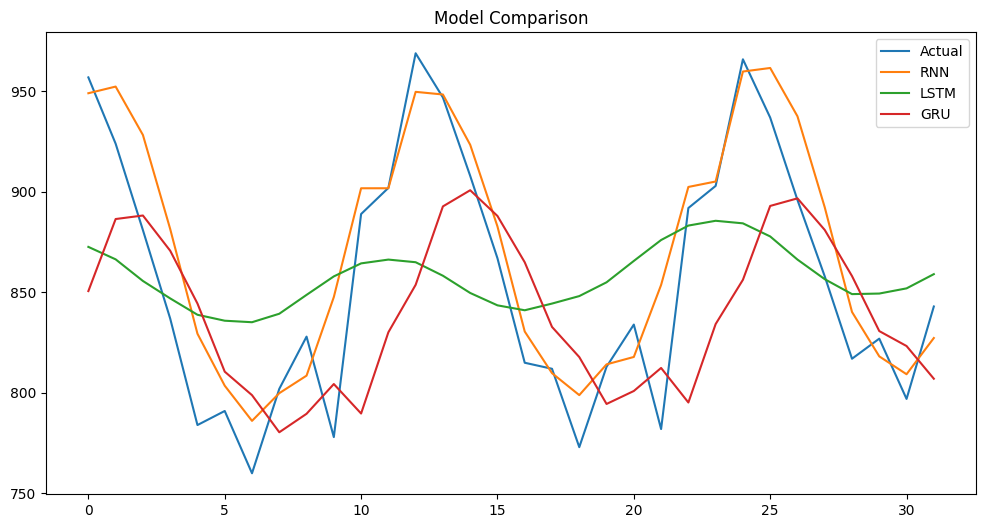

In [15]:
#Plot Predictions
plt.figure(figsize=(12,6))
plt.plot(rnn_metrics[4], label="Actual")
plt.plot(rnn_metrics[3], label="RNN")
plt.plot(lstm_metrics[3], label="LSTM")
plt.plot(gru_metrics[3], label="GRU")
plt.legend()
plt.title("Model Comparison")
plt.show()

In [16]:
#Future Forecast
def forecast(model, data, window_size, steps):
    temp_input = data[-window_size:].reshape(1, window_size, 1)
    forecast = []

    for _ in range(steps):
        pred = model.predict(temp_input)[0]
        forecast.append(pred)
        
        temp_input = np.append(temp_input[:,1:,:], [[pred]], axis=1)
    
    return scaler.inverse_transform(forecast)

future_preds = forecast(lstm_model, scaled_data, window_size, 12)

1/1 [==============================] - 0s 52ms/step


C:\Users\SUGANYA P\AppData\Local\Temp\ipykernel_24604\4051942340.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  plt.plot(pd.date_range(df.index[-1], periods=13, freq='M')[1:], future_preds, label="Forecast")


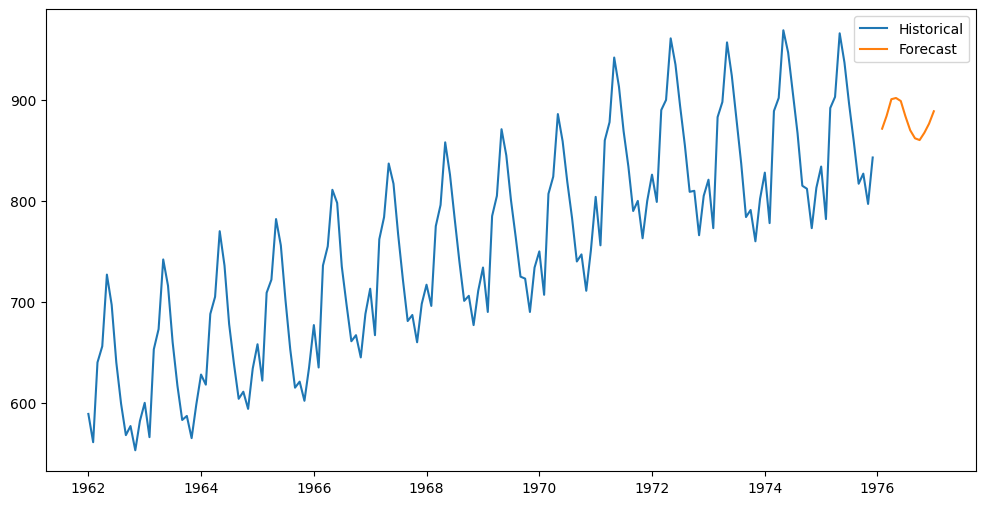

In [17]:
#Plot Forecast
plt.figure(figsize=(12,6))
plt.plot(df, label="Historical")
plt.plot(pd.date_range(df.index[-1], periods=13, freq='M')[1:], future_preds, label="Forecast")
plt.legend()
plt.show()

In [18]:
configs = [
    {'units': 32, 'epochs': 20, 'batch': 16},
    {'units': 50, 'epochs': 30, 'batch': 16},
    {'units': 64, 'epochs': 20, 'batch': 32}
]

results = []

for config in configs:
    model = Sequential([
        LSTM(config['units'], activation='relu', input_shape=(window_size,1)),
        Dense(1)
    ])
    
    model.compile(optimizer='adam', loss='mse')
    
    model.fit(X_train, y_train,
              epochs=config['epochs'],
              batch_size=config['batch'],
              verbose=0)
    
    rmse, mae, mape, _, _ = evaluate_model(model, X_test, y_test)
    
    results.append((config, rmse))

print("Hyperparameter Tuning Results:")
for config, rmse in results:
    print(config, "-> RMSE:", rmse)

1/1 [==============================] - 0s 385ms/step
Hyperparameter Tuning Results:
{'units': 32, 'epochs': 20, 'batch': 16} -> RMSE: 57.17322805802107
{'units': 50, 'epochs': 30, 'batch': 16} -> RMSE: 31.668092953374096
{'units': 64, 'epochs': 20, 'batch': 32} -> RMSE: 60.08476044330706
